# **Mount Drive**

# New Section

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
from matplotlib import pyplot as plt
import seaborn as sns
from glob import glob

In [ ]:
fpath1 = '<DATA_ROOT>/WeatherIndex/Temp_Tercile_11nov.csv'
fpath2 = '<DATA_ROOT>/WeatherIndex/Drought_Map.csv'
dft = pd.read_csv(fpath1)
dfd = pd.read_csv(fpath2)
dft

dfd = dfd.rename(columns={'Year':'year', 'STATE':'State', 'COUNTY':'County'})
fpath = '<DATA_ROOT>/WeatherIndex/svi2020fips.csv'
df_fips_obj = pd.read_csv(fpath)[['FIPS',	'OBJECTID']]
dfd = pd.merge(dfd,df_fips_obj,on=['OBJECTID']).drop(columns=['State','County','OBJECTID'])
# dfd.iloc[0:5,:]

dft = dft.rename(columns={'Year':'year'}).drop(columns=['State','County'])
# fpath = '<DATA_ROOT>/WeatherIndex/svi2020fips.csv'
# df_fips_obj = pd.read_csv(fpath)[['FIPS',	'OBJECTID']]
# dft = pd.merge(dft,df_fips_obj,on=['OBJECTID'])
# dft.iloc[0:5,:]

In [ ]:
import pandas as pd
fsvi = '<DATA_ROOT>/SVI/SVI_timeseries.csv'
df_svi = pd.read_csv(fsvi)
# df_svi = df_svi.sort_values(by=['State', 'County'])
df_svi = df_svi.drop(columns=['State', 'County'])
df_svi = df_svi.set_index(['FIPS','year'])


In [ ]:
bins = list(np.arange(0,101,5)/100)
labels = list(np.arange(0,100,5)/100)
df_svi = df_svi.apply(lambda x: pd.cut(x, bins=bins, labels=labels), axis=0)
df_svi = df_svi.reset_index()


In [ ]:
bins

In [ ]:
ffail = '<DATA_ROOT>/crop_failure_data/crops_failure_0595.csv'
df_fail = pd.read_csv(ffail)
df_fail = df_fail.drop(columns=['Unnamed: 0'])
df_fail = df_fail.sort_values(by=['FIPS'])
# cond1 = df_fail['year']>2011
cond2 = df_fail['Planted Acres'] > 0
df_fail = df_fail[cond2]
df_fail['fail_share'] = df_fail['Failed Acres'] /  df_fail['Planted Acres']
df_fail = df_fail[df_fail.fail_share < 1]
# df_fail.iloc[0:10,:]

In [ ]:
df_fail_agg = df_fail.groupby(['FIPS','Crop','year','Irrigation Practice']).mean().reset_index()
df_merge = pd.merge(df_fail_agg,df_svi,on=['FIPS','year'])
# df_merge

In [ ]:
theme = 'RPL_THEME4'
irig_type = 'Non-Irrigation'

cond1 = df_merge['Irrigation Practice'] == 'N'
df_CropAreaTheme = df_merge[cond1].groupby(['Crop',theme])['Planted Acres'].sum().reset_index()
df_CropAreaTheme = df_CropAreaTheme.pivot(index=theme,columns='Crop',values='Planted Acres')

cond1 = df_merge['Irrigation Practice'] == 'N'
df_CropFailTheme = df_merge[cond1].groupby(['Crop',theme]).mean().reset_index()
df_CropFailTheme = df_CropFailTheme.pivot(index=theme,columns='Crop',values='fail_share')



import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

crops = ['CORN', 'COTTON', 'OATS', 'SORGHUM', 'SOYBEANS', 'WHEAT', 'BARLEY', 'HAY']
fig, axes = plt.subplots(nrows=4, ncols=2,figsize=(16,10),dpi=400)
i = 0

for ax_row in axes:
    for ax in ax_row:

        ws = 4
        sns.lineplot(data=df_CropAreaTheme.rolling(window=ws, min_periods=1).mean(),
                     x=df_CropAreaTheme.index, y=crops[i], color='#bdbdbd', ax=ax)
        ax.fill_between(df_CropAreaTheme.index, 0,
                        df_CropAreaTheme[crops[i]].rolling(window=ws, min_periods=1).mean(),
                        color='#bdbdbd', alpha=0.3)

        ax_twin = ax.twinx()
        sns.lineplot(data=df_CropFailTheme.rolling(window=ws, min_periods=1).mean(),
                     x=df_CropFailTheme.index, y=crops[i], color='#fa9fb5', ax=ax_twin)
        ax_twin.fill_between(df_CropFailTheme.index, 0,
                             df_CropFailTheme[crops[i]].rolling(window=ws, min_periods=1).mean(),
                             color='#fa9fb5', alpha=0.3)

        ax.set_title(crops[i])
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel('')
        ax.set_ylabel('')

        if i > 5:
          ax.set_xticks(list(np.arange(0,11,2)/10))
          ax.set_xticklabels(list(np.arange(0,11,2)/10), fontsize=16)


        ax_twin.set_yticks([])
        ax_twin.set_xlabel('')
        ax_twin.set_ylabel('')

        i += 1

plt.suptitle(f'{irig_type} {theme}',fontsize=14)
out_path = '<DATA_ROOT>/ProcessedData/20231111-DensityPlot-FailurePlantArea/'
plt.savefig(out_path + theme + '_' + "".join(irig_type.split()) + '.jpg' , dpi=400)
# plt.tight_layout()
# plt.show()





# New Section

In [ ]:
# df_merge = pd.merge(df_fail_agg,df_svi,on=['FIPS','year'])
fail_cols = ['FIPS','year','Crop','Irrigation Practice','Planted Acres','Failed Acres','fail_share','RPL_THEME1']
df_merge = pd.merge(df_merge[fail_cols],dfd[['FIPS','year','SPEI3']],on=['FIPS','year'])


In [ ]:
cond1 = df_merge['Irrigation Practice'] == 'ALL'
# cond2 = df_merge['SPEI3'] != -1
df_FailTheme = df_merge[cond1].groupby(['Crop','RPL_THEME1']).sum().reset_index()
# df_FailDroughtTheme['fail_share'] = df_FailDroughtTheme['Failed Acres'] / df_FailDroughtTheme['Planted Acres']
df_FailTheme = df_FailTheme.pivot(index='RPL_THEME1',columns='Crop',values='Planted Acres')

cond1 = df_merge['Irrigation Practice'] == 'ALL'
cond2 = df_merge['SPEI3'] == -1
df_FailTheme_NonDr = df_merge[cond1 & cond2].groupby(['Crop','RPL_THEME1']).mean().reset_index()
# df_FailTheme['fail_share'] = df_FailTheme['Failed Acres'] / df_FailTheme['Planted Acres']
df_FailTheme_NonDr = df_FailTheme_NonDr.pivot(index='RPL_THEME1',columns='Crop',values='fail_share')


cond1 = df_merge['Irrigation Practice'] == 'ALL'
cond2 = df_merge['SPEI3'] != -1
df_FailTheme_Dr = df_merge[cond1 & cond2].groupby(['Crop','RPL_THEME1']).mean().reset_index()
# df_FailDroughtTheme['fail_share'] = df_FailDroughtTheme['Failed Acres'] / df_FailDroughtTheme['Planted Acres']
df_FailTheme_Dr = df_FailTheme_Dr.pivot(index='RPL_THEME1',columns='Crop',values='fail_share')


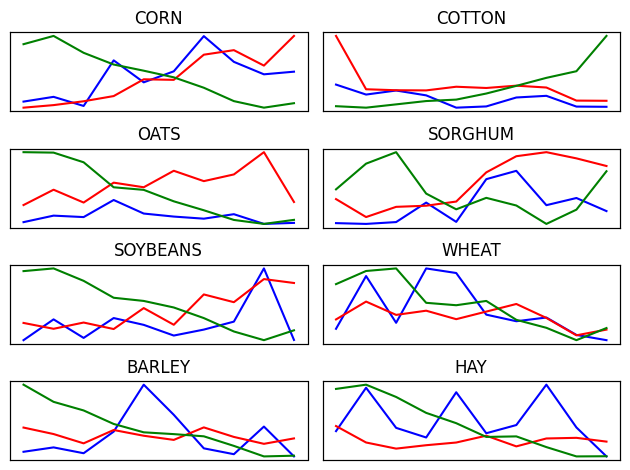

In [ ]:
import matplotlib.pyplot as plt

crops = ['CORN', 'COTTON', 'OATS', 'SORGHUM', 'SOYBEANS', 'WHEAT', 'BARLEY', 'HAY']
fig, axes = plt.subplots(nrows=4, ncols=2)
i = 0

for ax_row in axes:
    for ax in ax_row:
        ax.plot(df_FailTheme_NonDr[crops[i]], color='blue')
        ax.plot(df_FailTheme_Dr[crops[i]], color='red')
        ax_twin = ax.twinx()
        ax_twin.plot(df_FailTheme[crops[i]], label='Crop Fail', color='green')

        ax.set_title(crops[i])
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel('')
        ax.set_ylabel('')

        ax_twin.set_yticks([])
        ax_twin.set_xlabel('')
        ax_twin.set_ylabel('')

        i += 1

plt.tight_layout()
plt.show()
